# LLM-Driven Ontology Generation: Pipeline Demonstration

This notebook demonstrates the complete **Top-Down Skeleton + Bottom-Up Population** algorithm for generating RDF ontologies from a domain using LLMs.

We'll walk through all 4 phases:
1. **Structured Seed** — Generate a multi-level taxonomic skeleton
2. **Structural Validation** — Validate and prune the seed structure
3. **UCB1 Expansion** — Iteratively expand the ontology using a multi-armed bandit
4. **RDF Serialization** — Emit hierarchical RDF triples and visualize

## Setup

Configure the LLM client and ontology parameters.

In [1]:
import json
import os
from ontogen import ChatGpt, Ontology, OntologyLevel, DEFAULT_LEVEL_SCHEMA

# Configuration
DOMAIN = "Star Trek"  # Change this to explore other domains
API_KEY = os.getenv("OPENAI_API_KEY", "")
MODEL = "gpt-4o-mini"
SEED_SIZE = 3  # Number of top-level classes to seed
MAX_ITERATIONS = 20  # Max expansion iterations
EXPLORATION_CONSTANT = 2  # UCB1 exploration parameter
SIMILARITY_THRESHOLD = 85  # Minimum similarity (0-100) to accept relationships

print(f"Domain: {DOMAIN}")
print(f"API Key configured: {bool(API_KEY)}")
print(f"Default level schema: {[level.name for level in DEFAULT_LEVEL_SCHEMA]}")

Domain: Star Trek
API Key configured: True
Default level schema: ['class', 'subclass', 'instance']


In [2]:
# Initialize LLM client and ontology
agent = ChatGpt(api_key=API_KEY, model=MODEL)

ontology = Ontology(
    domain=DOMAIN,
    agent=agent,
    level_schema=DEFAULT_LEVEL_SCHEMA,
    exploration_constant=EXPLORATION_CONSTANT,
    max_iterations=MAX_ITERATIONS,
    similarity_threshold=SIMILARITY_THRESHOLD,
)

print(f"Ontology initialized for domain: {ontology.domain}")

Ontology initialized for domain: Star Trek


## Phase 1: Structured Seed

Generate a multi-level taxonomic skeleton from the domain using the LLM.
The seed captures the initial structure with classes, subclasses, and instances.

In [3]:
# Generate structured seed taxonomy
print(f"Generating {SEED_SIZE}-level taxonomic skeleton for '{DOMAIN}'...")
seed = ontology.generate_initial_terms(num_classes=SEED_SIZE)

if seed:
    print(f"\nSeed domain: {seed.get('domain')}")
    print(f"Number of top-level classes: {len(seed.get('taxonomy', []))}")
    print("\nRaw seed taxonomy (JSON):")
    print(json.dumps(seed, indent=2))
else:
    print("ERROR: Seed generation failed. Check API key and try again.")

Generating 3-level taxonomic skeleton for 'Star Trek'...

Seed domain: Star Trek
Number of top-level classes: 3

Raw seed taxonomy (JSON):
{
  "domain": "Star Trek",
  "taxonomy": [
    {
      "class": "Starfleet",
      "description": "The principal exploratory and defensive service in the United Federation of Planets.",
      "subclasses": [
        {
          "class": "Starfleet Vessels",
          "description": "Spacecraft used by Starfleet for exploration and defense.",
          "instances": [
            {
              "term": "USS Enterprise",
              "description": "An iconic Starfleet starship known for its exploration missions and key role in numerous Star Trek series."
            },
            {
              "term": "USS Defiant",
              "description": "A heavily armed warship designed for combat and tactical missions, introduced in 'Star Trek: Deep Space Nine.'"
            }
          ]
        },
        {
          "class": "Starfleet Officers",
    

## Phase 2: Structural Validation

Convert the seed to a graph and validate its structure using pairwise LLM similarity checks.
This phase prunes weak edges and identifies any orphaned nodes.

In [4]:
# Create DiGraph from seed
print("Converting seed taxonomy to internal graph...")
ontology.create_seed_ontology()

if ontology.ontology_graph.number_of_nodes() > 0:
    print(f"Graph created: {ontology.ontology_graph.number_of_nodes()} nodes, {ontology.ontology_graph.number_of_edges()} edges")
    print(f"\nNodes by level:")
    for level in DEFAULT_LEVEL_SCHEMA:
        nodes_at_level = [n for n, d in ontology.ontology_graph.nodes(data=True) if d.get('level') == level.name]
        print(f"  {level.name}: {len(nodes_at_level)} nodes ({', '.join(nodes_at_level[:3])}{'...' if len(nodes_at_level) > 3 else ''})")
else:
    print("ERROR: Graph creation failed.")

Converting seed taxonomy to internal graph...
Graph created: 21 nodes, 18 edges

Nodes by level:
  class: 3 nodes (Starfleet, Alien Species, Technology)
  subclass: 6 nodes (Starfleet Vessels, Starfleet Officers, Federation Species...)
  instance: 12 nodes (USS Enterprise, USS Defiant, Captain Jean-Luc Picard...)


In [5]:
# Validate structure: check parent-child, sibling, and cross-branch relationships
print("\nValidating structure with pairwise similarity checks...")
validation_summary = ontology.validate_structure()

print("\nValidation Summary:")
for key, value in validation_summary.items():
    print(f"  {key}: {value}")

print(f"\nGraph after validation: {ontology.ontology_graph.number_of_nodes()} nodes, {ontology.ontology_graph.number_of_edges()} edges")


Validating structure with pairwise similarity checks...


Pruned weak parent-child edge Starfleet Vessels (subclass) → USS Defiant (instance): similarity=80.0%
Pruned weak parent-child edge Starfleet Officers (subclass) → Captain Jean-Luc Picard (instance): similarity=70.0%
Pruned weak parent-child edge Starfleet Officers (subclass) → Commander Benjamin Sisko (instance): similarity=75.0%
Pruned weak parent-child edge Alien Species (class) → Federation Species (subclass): similarity=70.0%
Pruned weak parent-child edge Alien Species (class) → Hostile Species (subclass): similarity=70.0%
Pruned weak parent-child edge Federation Species (subclass) → Vulcans (instance): similarity=70.0%
Pruned weak parent-child edge Federation Species (subclass) → Humans (instance): similarity=80.0%
Pruned weak parent-child edge Hostile Species (subclass) → Borg (instance): similarity=80.0%
Pruned weak parent-child edge Technology (class) → Medical Technology (subclass): similarity=70.0%
Pruned weak parent-child edge Starship Technology (subclass) → Warp Drive (in


Validation Summary:
  edges_pruned: 13
  siblings_flagged: 2
  cross_branch_candidates: 0
  orphaned_nodes: 13

Graph after validation: 21 nodes, 5 edges


## Phase 3: UCB1 Expansion

Iteratively expand the ontology using a multi-armed bandit (UCB1) strategy.
For each iteration, we select the most promising expandable node and generate new candidates.

Running full pipeline with max_iterations=20...
Similarity threshold: 85
Exploration constant (UCB1): 2


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Phase 1: Seed Generation
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✓ Generated 5 top-level classes (26.6s)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Phase 2: Graph Construction
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✓ Created graph: 34 nodes, 29 edges (0.0s)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Phase 3: Structural Validation
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


Pruned weak parent-child edge Starships (class) → Federation Starships (subclass): similarity=80.0%
Pruned weak parent-child edge Federation Starships (subclass) → USS Enterprise (instance): similarity=80.0%
Pruned weak parent-child edge Federation Starships (subclass) → USS Voyager (instance): similarity=80.0%
Pruned weak parent-child edge Species (class) → Federation Species (subclass): similarity=70.0%
Pruned weak parent-child edge Species (class) → Antagonistic Species (subclass): similarity=70.0%
Pruned weak parent-child edge Federation Species (subclass) → Humans (instance): similarity=80.0%
Pruned weak parent-child edge Federation Species (subclass) → Vulcans (instance): similarity=70.0%
Pruned weak parent-child edge Antagonistic Species (subclass) → Borg (instance): similarity=70.0%
Pruned weak parent-child edge Antagonistic Species (subclass) → Klingons (instance): similarity=80.0%
Pruned weak parent-child edge Planets (class) → Federation Planets (subclass): similarity=80.0%


  ✓ Pruned 25 edges, 27 orphaned nodes (15.9s)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Phase 4: UCB1 Iterative Expansion
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Iter  Node                   Gen   Acc    Rate   Reward  Nodes  Edges  Status
  ────  ────────────────────  ────  ────  ──────  ───────  ─────  ─────  ────────────
     1  Starships               20     2    10%    0.850     36      7  
     2  Federation Starships    20     0     0%    0.000     36      7  stagnant(1)
     3  Romulan Starships       20     4    20%    0.850     40     13  plateau(1)
     4  Species                 20     0     0%    0.000     40     13  plateau(1) stagnant(1)
     5  Federation Species      21     0     0%    0.000     40     13  plateau(1) stagnant(2)
     6  Antagonistic Species    21     6    29%    0.850     46     21  plateau(2)
     7  Planets                 21     0     0%    0.000     46     21  plateau(2) stagnant(1)
     8  Federation 

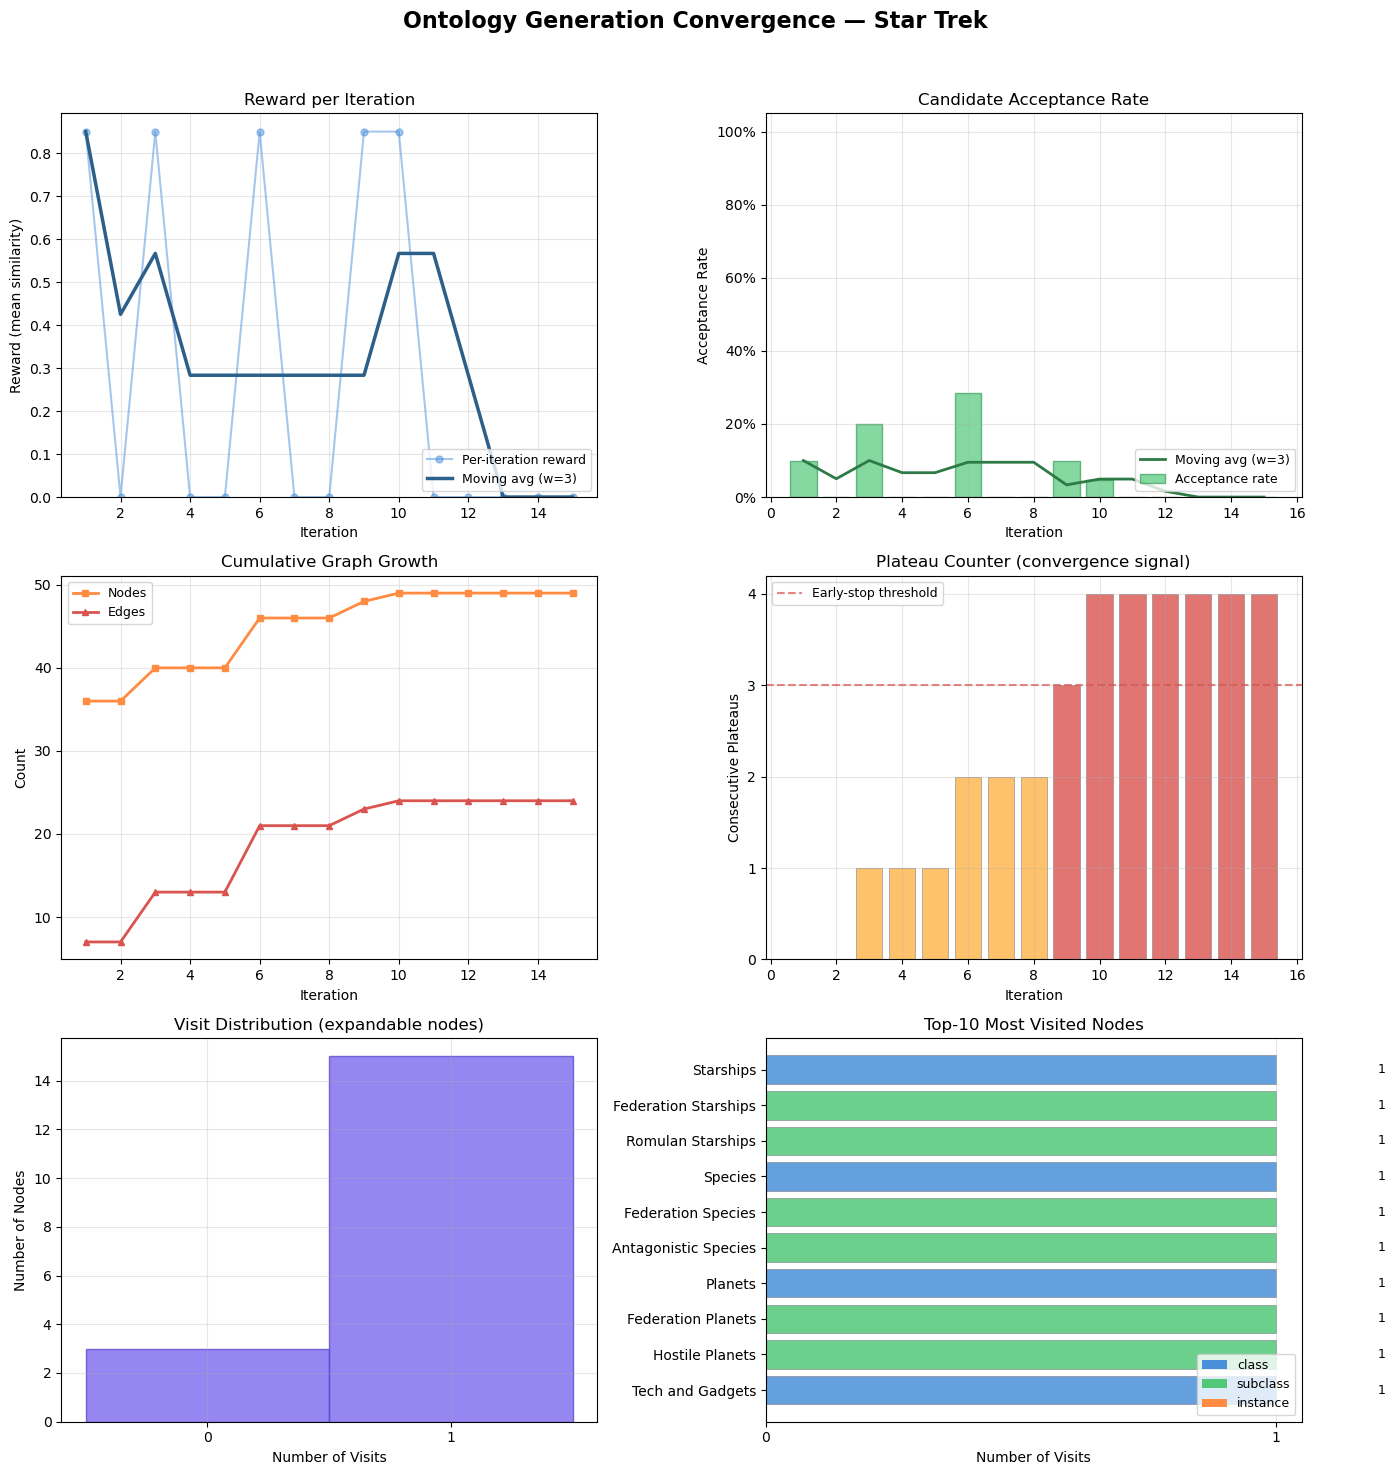


Pipeline complete!
Final graph: 49 nodes, 24 edges


In [6]:
# Run full generation pipeline (seed + validate + expand loop + serialize)
print(f"Running full pipeline with max_iterations={MAX_ITERATIONS}...")
print(f"Similarity threshold: {SIMILARITY_THRESHOLD}")
print(f"Exploration constant (UCB1): {EXPLORATION_CONSTANT}\n")

ontology.generate_ontology()

# Post-run audit
print(ontology.history.summary())      # formatted summary
df = ontology.history.to_dataframe()   # pandas DataFrame
ontology.plot_convergence()            # matplotlib convergence charts

print(f"\nPipeline complete!")
print(f"Final graph: {ontology.ontology_graph.number_of_nodes()} nodes, {ontology.ontology_graph.number_of_edges()} edges")

In [7]:
# Display expansion statistics
print("\nExpansion Statistics:")
print(f"Total nodes in final ontology: {ontology.ontology_graph.number_of_nodes()}")
print(f"Total edges in final ontology: {ontology.ontology_graph.number_of_edges()}")

# Count nodes by level
print(f"\nNodes by level:")
for level in DEFAULT_LEVEL_SCHEMA:
    nodes_at_level = [n for n, d in ontology.ontology_graph.nodes(data=True) if d.get('level') == level.name]
    print(f"  {level.name}: {len(nodes_at_level)} nodes")

# Show UCB1 bandit statistics
print(f"\nUCB1 Bandit Statistics (node selection):")
if hasattr(ontology, 'bandit_stats') and ontology.bandit_stats:
    for node, stats in sorted(ontology.bandit_stats.items(), key=lambda x: x[1]['n_visits'], reverse=True)[:5]:
        visits = stats.get('n_visits', 0)
        reward = stats.get('total_reward', 0.0)
        mean_reward = reward / visits if visits > 0 else 0
        print(f"  {node}: {visits} visits, avg reward = {mean_reward:.2f}")
else:
    print("  (Bandit statistics not available)")


Expansion Statistics:
Total nodes in final ontology: 49
Total edges in final ontology: 24

Nodes by level:
  class: 5 nodes
  subclass: 13 nodes
  instance: 31 nodes

UCB1 Bandit Statistics (node selection):
  (Bandit statistics not available)


## Phase 4: RDF Serialization

Convert the expanded ontology to RDF triples and serialize to standard formats (Turtle, XML, JSON-LD).

In [8]:
# Build RDF graph from the ontology
print("Building RDF graph from ontology...")
ontology.build_ontology()

if ontology.rdf is not None:
    num_triples = len(ontology.rdf)
    print(f"RDF graph built: {num_triples} triples")
else:
    print("ERROR: RDF graph construction failed.")

Building RDF graph from ontology...
RDF graph built: 91 triples


In [9]:
# Serialize to Turtle format
print("Serializing ontology to Turtle format...")
turtle_output = ontology.serialize_ontology(format="turtle")

# Display first 50 lines of Turtle output
print("\nTurtle Output (first 50 lines):")
lines = turtle_output.split('\n')
for line in lines[:50]:
    print(line)

if len(lines) > 50:
    print(f"... ({len(lines) - 50} more lines)")

Serializing ontology to Turtle format...

Turtle Output (first 50 lines):
@prefix ex: <http://example.org/ontology/> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .

ex:Alien_Characters a rdfs:Class ;
    rdfs:label "Alien Characters" .

ex:Alien_Technology a rdfs:Class ;
    rdfs:label "Alien Technology" ;
    rdfs:subClassOf ex:Tech_and_Gadgets .

ex:Antagonistic_Species a rdfs:Class ;
    rdfs:label "Antagonistic Species" .

ex:Borg_Cubes a rdfs:Class ;
    rdfs:label "Borg Cubes" ;
    rdfs:subClassOf ex:Starships .

ex:Characters a rdfs:Class ;
    rdfs:label "Characters" .

ex:Federation_Planets a rdfs:Class ;
    rdfs:label "Federation Planets" .

ex:Federation_Species a rdfs:Class ;
    rdfs:label "Federation Species" .

ex:Federation_Starships a rdfs:Class ;
    rdfs:label "Federation Starships" .

ex:Hostile_Planets a rdfs:Class ;
    rdfs:label "Hostile Planets" .

ex:Planets a rdfs:Class ;
    rdfs:label "Planets" .

ex:Romulan_Starships a rdfs:Class ;
    rdfs:la

In [10]:
# Save to file
output_path = "../output/ontology.ttl"
os.makedirs(os.path.dirname(output_path), exist_ok=True)

with open(output_path, 'w') as f:
    f.write(turtle_output)

print(f"Ontology saved to: {output_path}")
print(f"File size: {os.path.getsize(output_path)} bytes")

Ontology saved to: ../output/ontology.ttl
File size: 3462 bytes


## Visualization

Visualize the ontology structure both as an RDF graph and an internal DiGraph with level-based coloring.

Rendering RDF graph (via rdf2dot/graphviz)...


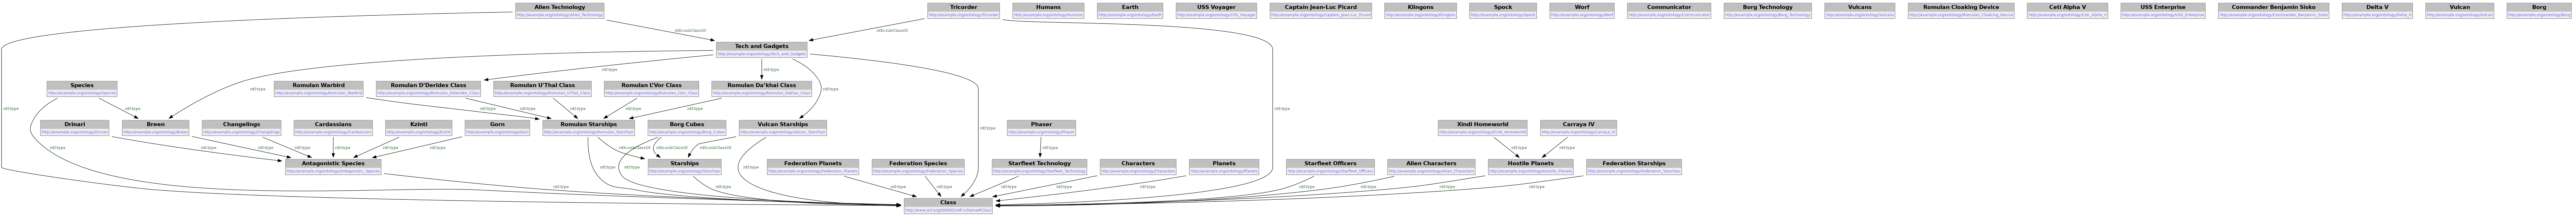

In [11]:
# Visualize the RDF graph
print("Rendering RDF graph (via rdf2dot/graphviz)...")
try:
    ontology.visualize()
except Exception as e:
    print(f"Note: RDF visualization requires graphviz. Error: {e}")

In [12]:
# Interactive full-page HTML graph (pyvis)
print("Rendering interactive HTML graph...")
html_path = ontology.visualize_interactive(output_path="ontology.html")
print(f"Interactive graph saved to: {html_path}")
print("Open the HTML file in a browser for full-page pan-and-zoom exploration.")

Rendering interactive HTML graph...
ontology.html
Interactive graph saved to: /workspaces/thesis-llml-onthology/notebooks/ontology.html
Open the HTML file in a browser for full-page pan-and-zoom exploration.


Rendering internal DiGraph with level-based coloring...


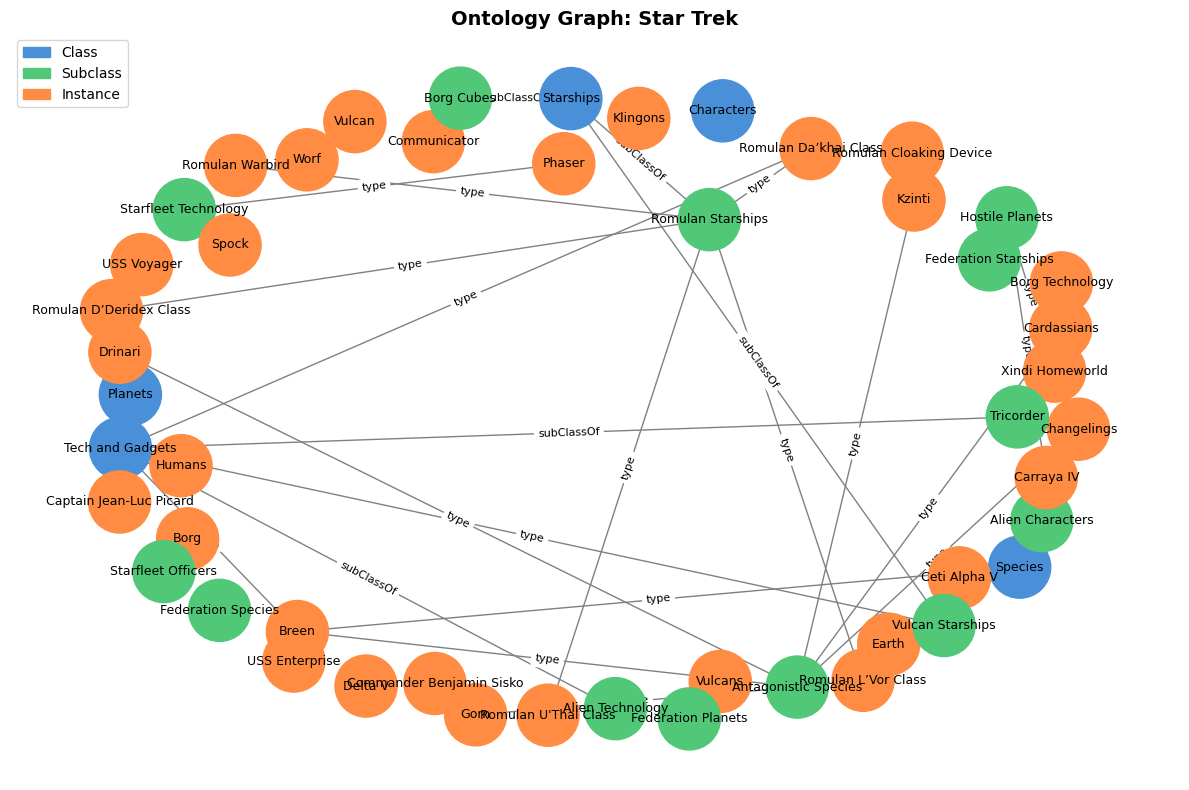

In [13]:
# Visualize the internal DiGraph with level-based node coloring
print("Rendering internal DiGraph with level-based coloring...")
try:
    ontology.visualize_graph()
except Exception as e:
    print(f"Note: DiGraph visualization requires matplotlib. Error: {e}")